# 📊 Taller de Visualización de Datos con `ggplot2`
## Duración · 1.5 horas

---

> **Instructor:** Boris Rebolledo | brebolledo@udd.cl | Universidad del Desarrollo.  
> **Fecha:** 20 de mayo de 2026  
> **Nivel:** Principiante – Intermedio

---

## 🧬 ¿Por qué visualizar datos en investigación biomédica?

Una buena visualización puede:

- **Revelar patrones ocultos** que el análisis descriptivo pasa por alto.
- **Comunicar resultados** de manera efectiva a audiencias científicas y clínicas.
- **Detectar errores y outliers** antes de modelar.
- **Facilitar decisiones clínicas** al presentar desenlaces y respuestas a tratamientos.

### El Cuarteto de Anscombe [(Wikipedia)](https://es.wikipedia.org/wiki/Cuarteto_de_Anscombe)

Cuatro datasets completamente distintos comparten la misma media, varianza y correlación. Solo al graficarlos emergen sus diferencias. En biomedicina este problema es real: dos brazos de un ensayo pueden tener la misma media de un biomarcador pero distribuciones completamente distintas.

### ¿Por qué `ggplot2`?

`ggplot2` implementa la **Gramática de Gráficos** (Wilkinson 2005): el gráfico se construye por capas:

```
Datos → Estéticas (aes) → Geometría (geom) → Facetas → Escalas → Temas
```

---

## 📦 Datos del taller: paquete `medicaldata`

### 🏥 Dataset principal: `indo_rct` (randomized clinical trial)

**RCT doble ciego: Indometacina rectal vs. placebo para prevención de pancreatitis post-CPRE**

> Elmunzer BJ, et al. *A randomized trial of rectal indomethacin to prevent post-ERCP pancreatitis.*  
> **New England Journal of Medicine**, 2012; 366:1414–1422.

- **N:** 602 pacientes de alto riesgo, 4 centros de EE.UU.
- **Desenlace primario:** Pancreatitis post-CPRE (definida por consenso)



---

## 🗺️ Estructura del Taller

| Bloque | Duración | Contenido |
|--------|----------|-----------|
| 0 | 10 min | Configuración y exploración de datos |
| 1 | 20 min | Fundamentos de ggplot2 |
| 2 | 25 min | Geometrías y personalización |
| 3 | 25 min | Gráficos avanzados para publicación |
| 4 | 10 min | Ejercicio integrador y cierre |

---
## 🔧 Bloque 0 · Configuración (10 min)

In [1]:
# Instalar paquetes (solo la primera vez)
install.packages(c("ggplot2", "dplyr", "tidyr", "scales",
                    "medicaldata", "ggpubr", "patchwork"))

library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(medicaldata)
library(ggpubr)
library(patchwork)

theme_set(theme_bw(base_size = 13))
cat("Paquetes cargados correctamente.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘corrplot’, ‘car’, ‘ggrepel’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Paquetes cargados correctamente.


In [2]:
# Cargar dataset principal
indo <- medicaldata::indo_rct

cat("=== indo_rct: RCT de Indometacina (NEJM 2012) ===\n")
cat("Filas:", nrow(indo), "| Columnas:", ncol(indo), "\n\n")
glimpse(indo)

=== indo_rct: RCT de Indometacina (NEJM 2012) ===
Filas: 602 | Columnas: 33 

Rows: 602
Columns: 33
$ id          <dbl> 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010…
$ site        <fct> 1_UM, 1_UM, 1_UM, 1_UM, 1_UM, 1_UM, 1_UM, 1_UM, 1_UM, 1_UM…
$ age         <dbl> 26, 24, 57, 29, 38, 59, 60, 29, 53, 20, 51, 19, 57, 44, 33…
$ risk        <dbl> 2.0, 1.0, 1.0, 2.0, 3.5, 3.0, 1.5, 1.0, 2.0, 2.0, 3.0, 2.5…
$ gender      <fct> 1_female, 2_male, 1_female, 1_female, 1_female, 1_female, …
$ outcome     <fct> 1_yes, 0_no, 0_no, 1_yes, 0_no, 0_no, 0_no, 0_no, 0_no, 0_…
$ sod         <fct> 1_yes, 0_no, 1_yes, 1_yes, 1_yes, 1_yes, 0_no, 0_no, 0_no,…
$ pep         <fct> 0_no, 1_yes, 0_no, 0_no, 1_yes, 0_no, 0_no, 0_no, 0_no, 0_…
$ recpanc     <fct> 1_yes, 0_no, 0_no, 0_no, 0_no, 0_no, 1_yes, 0_no, 1_yes, 0…
$ psphinc     <fct> 0_no, 0_no, 0_no, 0_no, 1_yes, 0_no, 0_no, 0_no, 0_no, 0_n…
$ precut      <fct> 0_no, 0_no, 0_no, 0_no, 0_no, 1_yes, 0_no, 0_no, 0_no, 1_y…
$ difcan      <fct> 

In [3]:
# Explorar las variables clave
# NOTA: las variables categóricas son factores con etiquetas como "0_no" / "1_yes"

cat("── Tratamiento (rx):\n")
print(table(indo$rx))

cat("\n── Desenlace primario (outcome):\n")
print(table(indo$outcome))

cat("\n── Sexo (gender):\n")
print(table(indo$gender))

cat("\n── Pancreatitis previa (pep):\n")
print(table(indo$pep))

cat("\n── Resumen variables numéricas:\n")
indo %>% select(age, risk) %>% summary() %>% print()

cat("\n📖 Diccionario de variables clave:\n")
cat("  rx      : 0_placebo = Placebo | 1_indomethacin = Indometacina\n")
cat("  outcome : 0_no = Sin pancreatitis | 1_yes = Pancreatitis post-CPRE\n")
cat("  gender  : 1_female = Femenino | 2_male = Masculino\n")
cat("  age     : Edad del paciente (años)\n")
cat("  risk    : Puntaje de riesgo compuesto (suma de factores de riesgo)\n")
cat("  pep     : Pancreatitis post-CPRE previa (0_no / 1_yes)\n")
cat("  sod     : Disfunción del esfínter de Oddi (0_no / 1_yes)\n")
cat("  site    : Centro clínico (1_UM, 2_IU, 3_UC, 4_Case)\n")

── Tratamiento (rx):

     0_placebo 1_indomethacin 
           307            295 

── Desenlace primario (outcome):

 0_no 1_yes 
  523    79 

── Sexo (gender):

1_female   2_male 
     476      126 

── Pancreatitis previa (pep):

 0_no 1_yes 
  506    96 

── Resumen variables numéricas:
      age             risk      
 Min.   :19.00   Min.   :1.000  
 1st Qu.:35.00   1st Qu.:1.500  
 Median :45.00   Median :2.500  
 Mean   :45.27   Mean   :2.381  
 3rd Qu.:54.00   3rd Qu.:3.000  
 Max.   :90.00   Max.   :5.500  

📖 Diccionario de variables clave:
  rx      : 0_placebo = Placebo | 1_indomethacin = Indometacina
  outcome : 0_no = Sin pancreatitis | 1_yes = Pancreatitis post-CPRE
  gender  : 1_female = Femenino | 2_male = Masculino
  age     : Edad del paciente (años)
  risk    : Puntaje de riesgo compuesto (suma de factores de riesgo)
  pep     : Pancreatitis post-CPRE previa (0_no / 1_yes)
  sod     : Disfunción del esfínter de Oddi (0_no / 1_yes)
  site    : Centro clínico (1_UM

In [4]:
# Crear versión con etiquetas legibles en español
# Los niveles del factor se mapean explícitamente

indo_clean <- indo %>%
  mutate(
    tratamiento  = recode(as.character(rx),
                          "0_placebo"      = "Placebo",
                          "1_indomethacin" = "Indometacina"),
    pancreatitis = recode(as.character(outcome),
                          "0_no"  = "No",
                          "1_yes" = "Sí"),
    sexo         = recode(as.character(gender),
                          "1_female" = "Femenino",
                          "2_male"   = "Masculino"),
    pep_prev     = recode(as.character(pep),
                          "0_no"  = "No",
                          "1_yes" = "Sí"),
    sod_dx       = recode(as.character(sod),
                          "0_no"  = "No",
                          "1_yes" = "Sí"),
    tratamiento  = factor(tratamiento, levels = c("Placebo", "Indometacina")),
    pancreatitis = factor(pancreatitis, levels = c("No", "Sí")),
    sexo         = factor(sexo, levels = c("Femenino", "Masculino"))
  )

cat("Dataset indo_clean preparado:\n")
head(indo_clean %>% select(tratamiento, pancreatitis, sexo, pep_prev, age, risk))

Dataset indo_clean preparado:


tratamiento,pancreatitis,sexo,pep_prev,age,risk
<fct>,<fct>,<fct>,<chr>,<dbl>,<dbl>
Indometacina,Sí,Femenino,No,26,2.0
Placebo,No,Masculino,Sí,24,1.0
Placebo,No,Femenino,No,57,1.0
Placebo,Sí,Femenino,No,29,2.0
Indometacina,No,Femenino,Sí,38,3.5
Placebo,No,Femenino,No,59,3.0


---
## 🟢 Bloque 1 · Fundamentos de `ggplot2` (20 min)

### La fórmula básica

```r
ggplot(data = <DATOS>, aes(x = <VAR_X>, y = <VAR_Y>)) +
  geom_<TIPO>()
```

- `ggplot()` → inicializa el lienzo con datos y estéticas globales
- `aes()` → mapea variables a propiedades visuales
- `geom_*()` → define la geometría
- Las capas se unen con `+`

---

### Ejercicio 1.1 · Distribución de edad de los pacientes

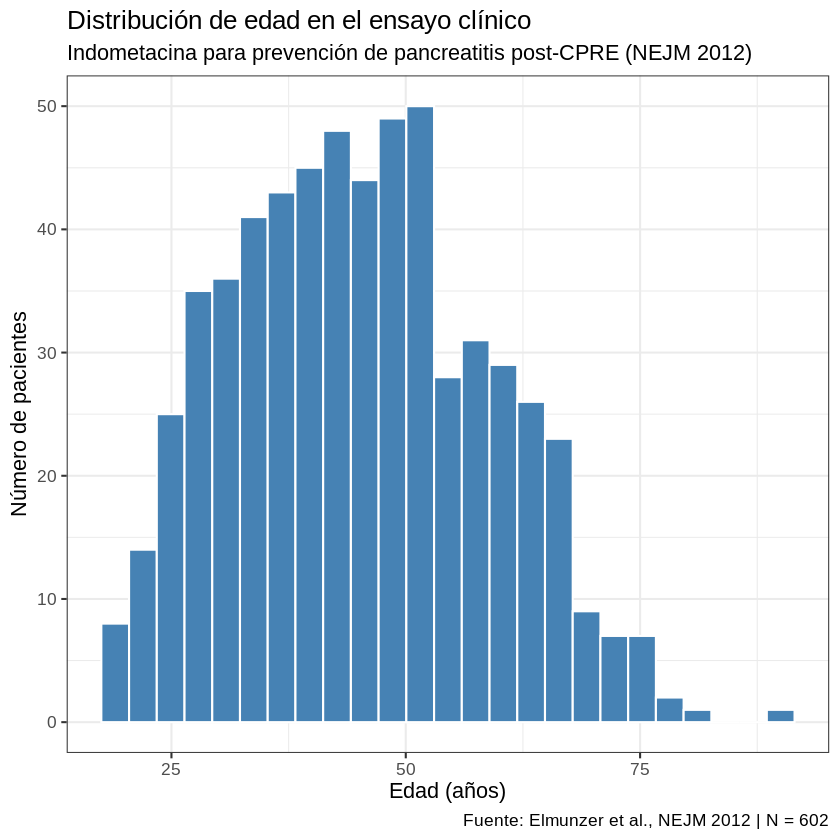

In [5]:
# Ejercicio 1.1: Histograma de edad
# Pregunta clínica: ¿Cómo se distribuye la edad en este ensayo?

ggplot(data = indo_clean, aes(x = age)) +
  geom_histogram(bins = 25, fill = "steelblue", color = "white") +
  labs(
    title   = "Distribución de edad en el ensayo clínico",
    subtitle = "Indometacina para prevención de pancreatitis post-CPRE (NEJM 2012)",
    x = "Edad (años)",
    y = "Número de pacientes",
    caption = "Fuente: Elmunzer et al., NEJM 2012 | N = 602"
  )

💡 La distribución se centra alrededor de los 45–50 años, típico para procedimientos de CPRE.

---

### Ejercicio 1.2 · Balance de edad entre grupos (verificación de aleatorización)

tratamiento,n,media_edad,de_edad
<fct>,<int>,<dbl>,<dbl>
Placebo,307,46.0,13.1
Indometacina,295,44.5,13.5


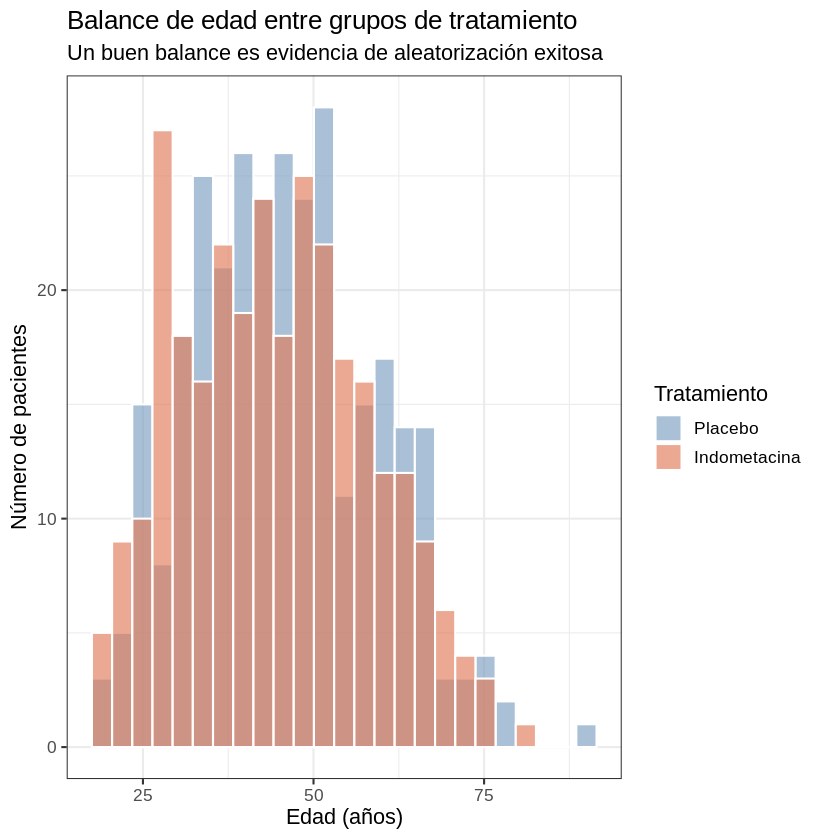

In [6]:
# Ejercicio 1.2: ¿Están los grupos balanceados en edad?
# Mapear 'fill' al tratamiento superpone las distribuciones

ggplot(indo_clean, aes(x = age, fill = tratamiento)) +
  geom_histogram(bins = 25, alpha = 0.65, position = "identity", color = "white") +
  scale_fill_manual(values = c("Placebo" = "#7B9EC1", "Indometacina" = "#E07B5A")) +
  labs(
    title    = "Balance de edad entre grupos de tratamiento",
    subtitle = "Un buen balance es evidencia de aleatorización exitosa",
    x = "Edad (años)", y = "Número de pacientes", fill = "Tratamiento"
  )

# Verificar numéricamente
indo_clean %>%
  group_by(tratamiento) %>%
  summarise(n = n(),
            media_edad = round(mean(age), 1),
            de_edad    = round(sd(age), 1))

💡 **Concepto clave:** Verificar el balance de covariables basales es el primer paso del análisis de cualquier RCT.

---

### Ejercicio 1.3 · Desenlace primario: incidencia de pancreatitis por grupo

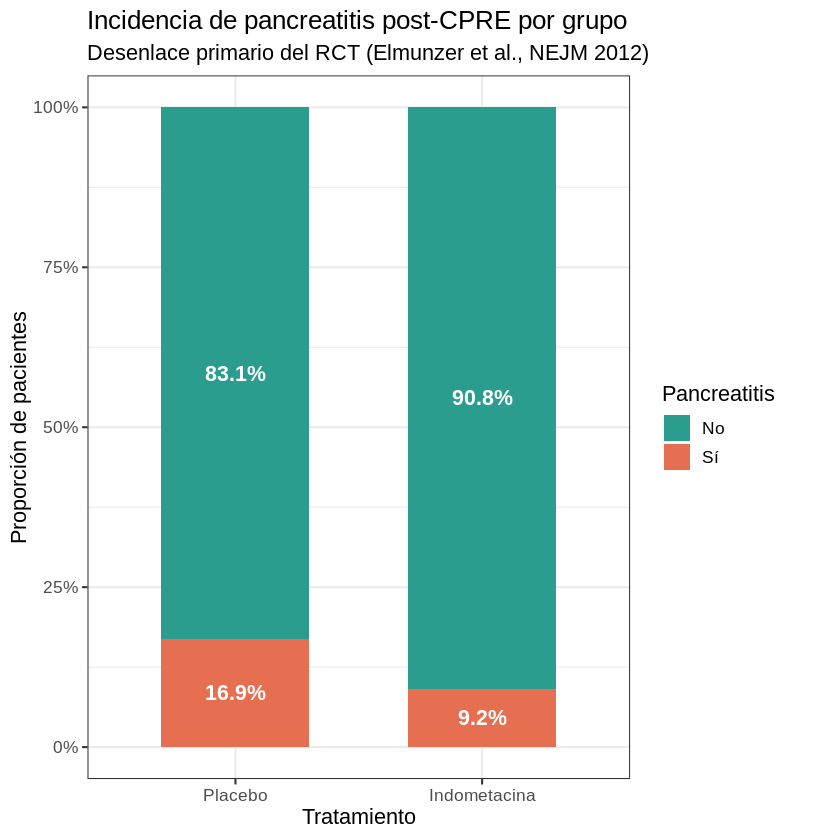

In [7]:
# Ejercicio 1.3: ¿Redujo la indometacina la incidencia de pancreatitis?

prop_pep <- indo_clean %>%
  count(tratamiento, pancreatitis) %>%
  group_by(tratamiento) %>%
  mutate(proporcion = n / sum(n),
         etiqueta   = paste0(round(proporcion * 100, 1), "%"))

ggplot(prop_pep, aes(x = tratamiento, y = proporcion, fill = pancreatitis)) +
  geom_col(position = "fill", width = 0.6) +
  geom_text(aes(label = etiqueta),
            position = position_fill(vjust = 0.5),
            color = "white", fontface = "bold", size = 4.5) +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("No" = "#2A9D8F", "Sí" = "#E76F51")) +
  labs(
    title    = "Incidencia de pancreatitis post-CPRE por grupo",
    subtitle = "Desenlace primario del RCT (Elmunzer et al., NEJM 2012)",
    x = "Tratamiento", y = "Proporción de pacientes", fill = "Pancreatitis"
  )

💡 La indometacina redujo la incidencia de ~17% a ~9% (p = 0.005). Este resultado cambió la práctica clínica mundial de la CPRE.

---

### 🧠 Ejercicio rápido (3 min)

Crea un histograma del puntaje de riesgo (`risk`) coloreado por `sexo`. Usa `bins = 20` y agrega título y etiquetas de ejes.

In [ ]:
# 🖊️ Tu código aquí:



---
## 🟡 Bloque 2 · Geometrías y personalización (25 min)

### Ejercicio 2.1 · Boxplot: puntaje de riesgo basal por grupo

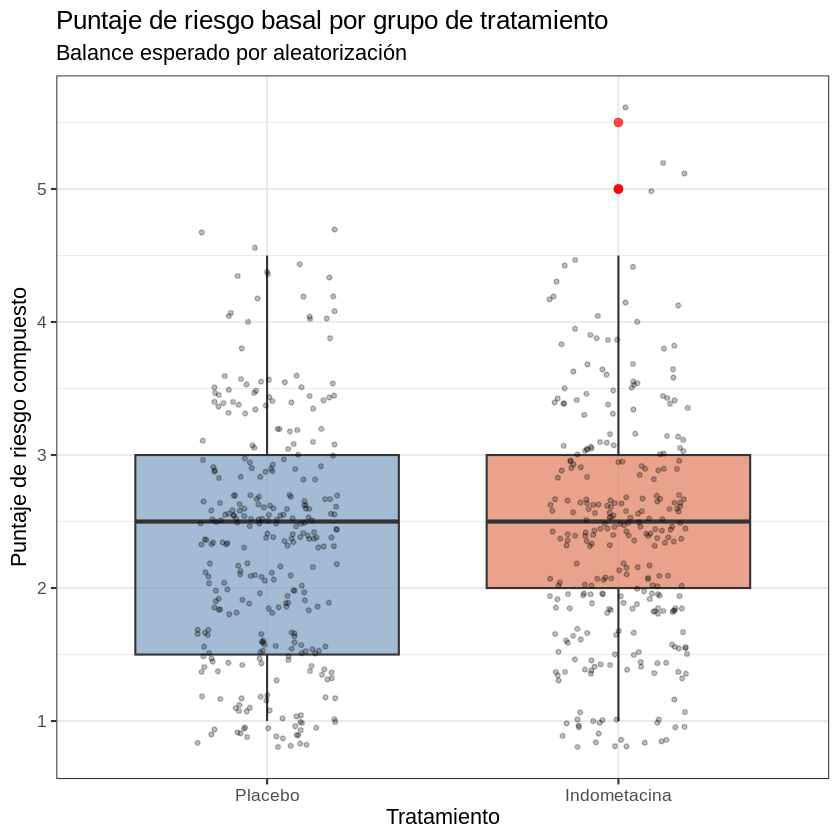

In [8]:
# Ejercicio 2.1: Boxplot + jitter
# Pregunta: ¿Está el riesgo basal balanceado entre grupos?

ggplot(indo_clean, aes(x = tratamiento, y = risk, fill = tratamiento)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red", outlier.size = 2) +
  geom_jitter(width = 0.2, alpha = 0.25, size = 1) +
  scale_fill_manual(values = c("Placebo" = "#7B9EC1", "Indometacina" = "#E07B5A")) +
  labs(
    title   = "Puntaje de riesgo basal por grupo de tratamiento",
    subtitle = "Balance esperado por aleatorización",
    x = "Tratamiento", y = "Puntaje de riesgo compuesto"
  ) +
  theme(legend.position = "none")

💡 **Buena práctica:** Combinar `geom_boxplot()` con `geom_jitter()` muestra distribución resumida Y datos individuales. Fundamental con muestras pequeñas o distribuciones asimétricas.

---

### Ejercicio 2.2 · Facetas: desenlace por grupo y sexo

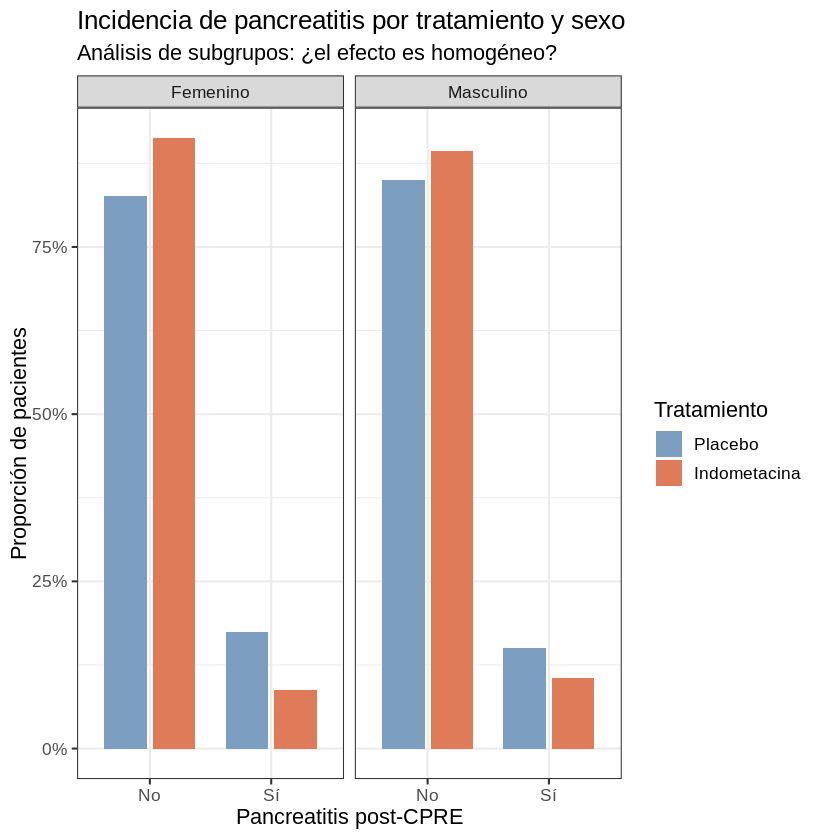

In [9]:
# Ejercicio 2.2: Gráfico de barras facetado por sexo
# Pregunta: ¿El efecto de la indometacina difiere entre hombres y mujeres?

conteo <- indo_clean %>%
  count(tratamiento, sexo, pancreatitis) %>%
  group_by(tratamiento, sexo) %>%
  mutate(prop = n / sum(n))

ggplot(conteo, aes(x = pancreatitis, y = prop, fill = tratamiento)) +
  geom_col(position = position_dodge(0.8), width = 0.7) +
  facet_wrap(~ sexo) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  scale_fill_manual(values = c("Placebo" = "#7B9EC1", "Indometacina" = "#E07B5A")) +
  labs(
    title    = "Incidencia de pancreatitis por tratamiento y sexo",
    subtitle = "Análisis de subgrupos: ¿el efecto es homogéneo?",
    x = "Pancreatitis post-CPRE", y = "Proporción de pacientes", fill = "Tratamiento"
  )

---

### Ejercicio 2.3 · Scatter plot: edad vs. puntaje de riesgo según desenlace

`geom_smooth()` using formula = 'y ~ x'


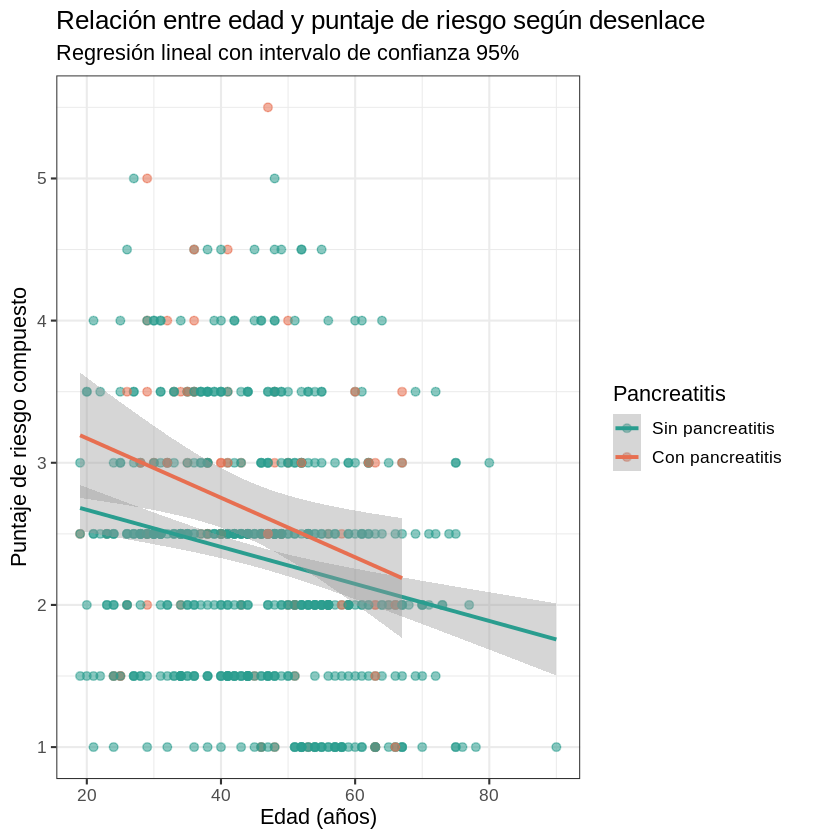

In [10]:
# Ejercicio 2.3: Dispersión edad vs. riesgo coloreado por desenlace
# Pregunta: ¿Los pacientes que desarrollaron pancreatitis tenían mayor riesgo basal?

ggplot(indo_clean, aes(x = age, y = risk, color = pancreatitis)) +
  geom_point(alpha = 0.55, size = 2) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 1.1) +
  scale_color_manual(
    values = c("No" = "#2A9D8F", "Sí" = "#E76F51"),
    labels = c("No" = "Sin pancreatitis", "Sí" = "Con pancreatitis")
  ) +
  labs(
    title    = "Relación entre edad y puntaje de riesgo según desenlace",
    subtitle = "Regresión lineal con intervalo de confianza 95%",
    x = "Edad (años)", y = "Puntaje de riesgo compuesto", color = "Pancreatitis"
  )

---

### Ejercicio 2.4 · Barras de error: media ± SE por grupo y pancreatitis previa

# A tibble: 4 × 5
  tratamiento  pep_prev     n media    se
  <fct>        <chr>    <int> <dbl> <dbl>
1 Placebo      No         258  46.6 0.814
2 Placebo      Sí          49  42.9 1.84 
3 Indometacina No         248  45.2 0.873
4 Indometacina Sí          47  40.6 1.67 


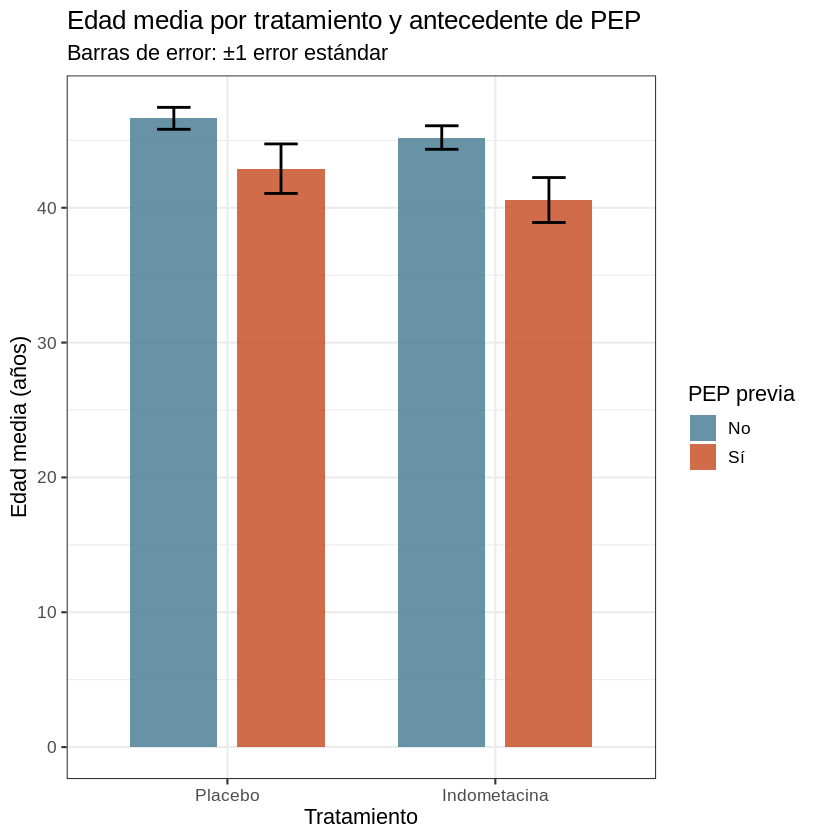

In [11]:
# Ejercicio 2.4: Edad media ± error estándar
# Pregunta: ¿Difiere la edad según si el paciente tenía PEP previa y el grupo de tratamiento?

resumen <- indo_clean %>%
  group_by(tratamiento, pep_prev) %>%
  summarise(
    n     = n(),
    media = mean(age, na.rm = TRUE),
    se    = sd(age, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

print(resumen)

ggplot(resumen, aes(x = tratamiento, y = media, fill = pep_prev)) +
  geom_col(position = position_dodge(0.8), width = 0.65, alpha = 0.85) +
  geom_errorbar(
    aes(ymin = media - se, ymax = media + se),
    position = position_dodge(0.8), width = 0.25, linewidth = 0.8
  ) +
  scale_fill_manual(values = c("No" = "#4E8098", "Sí" = "#C7522B")) +
  labs(
    title    = "Edad media por tratamiento y antecedente de PEP",
    subtitle = "Barras de error: ±1 error estándar",
    x = "Tratamiento", y = "Edad media (años)", fill = "PEP previa"
  )

---
## 🔴 Bloque 3 · Gráficos avanzados para publicación (25 min)

---

### Ejercicio 3.1 · Violin plot + prueba estadística (ggpubr)

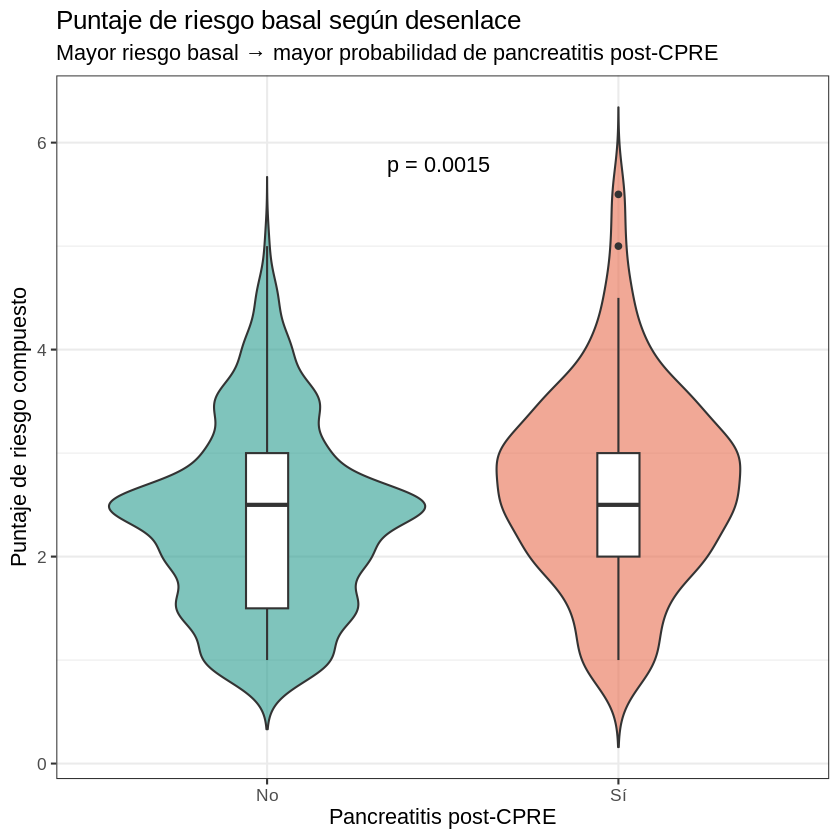

In [12]:
# Ejercicio 3.1: Violin + boxplot interior + Mann-Whitney
# Pregunta: ¿Tenían mayor puntaje de riesgo los pacientes que desarrollaron pancreatitis?

p_violin <- ggplot(indo_clean, aes(x = pancreatitis, y = risk, fill = pancreatitis)) +
  geom_violin(trim = FALSE, alpha = 0.6) +
  geom_boxplot(width = 0.12, fill = "white", outlier.size = 1.5) +
  scale_fill_manual(values = c("No" = "#2A9D8F", "Sí" = "#E76F51")) +
  labs(
    title    = "Puntaje de riesgo basal según desenlace",
    subtitle = "Mayor riesgo basal → mayor probabilidad de pancreatitis post-CPRE",
    x = "Pancreatitis post-CPRE", y = "Puntaje de riesgo compuesto"
  ) +
  theme(legend.position = "none")

# Agregar comparación estadística (Mann-Whitney U)
p_violin +
  ggpubr::stat_compare_means(
    method  = "wilcox.test",
    label   = "p.format",
    label.x = 1.4,
    label.y = max(indo_clean$risk, na.rm = TRUE) * 1.04
  )

---

### Ejercicio 3.2 · Heatmap de correlaciones entre variables de riesgo

En `indo_rct`, la mayoría de los factores de riesgo son binarios (0/1). Podemos calcular correlaciones de Spearman para detectar colinealidad antes de modelar.

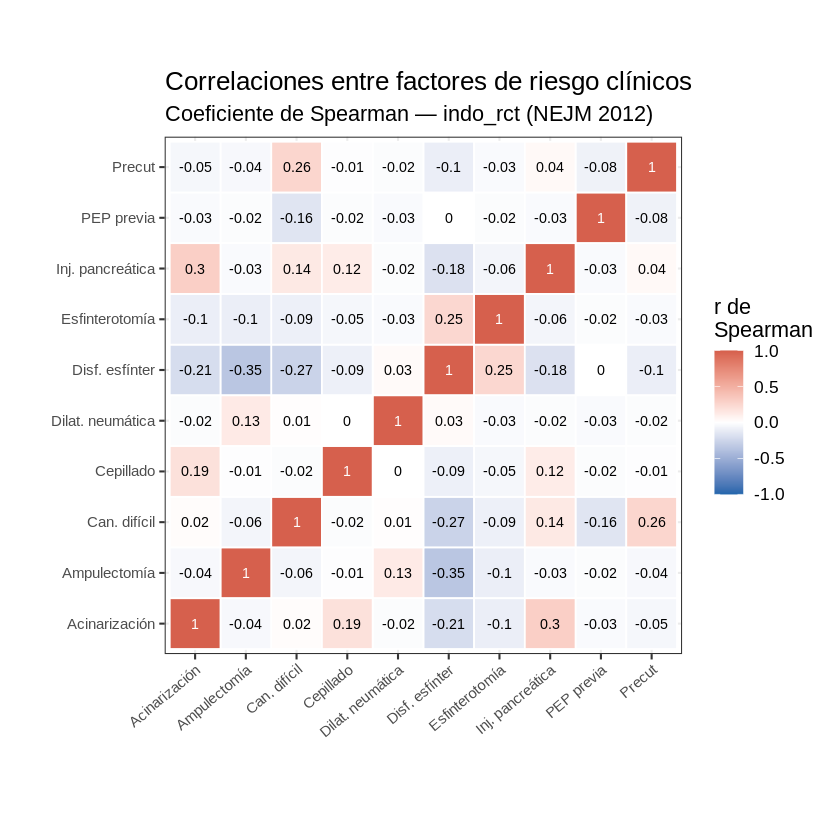

In [13]:
# Ejercicio 3.2: Heatmap de correlación de Spearman
# Convertimos variables factor a numérico (0/1) para calcular correlaciones

vars_bin <- indo %>%
  select(pep, sod, psphinc, precut, difcan, pneudil, amp, paninj, acinar, brush) %>%
  mutate(across(everything(), ~ as.integer(.) - 1)) %>%
  na.omit()

cor_mat <- cor(vars_bin, method = "spearman") %>% round(2)

etiquetas <- c(
  pep     = "PEP previa",
  sod     = "Disf. esfínter",
  psphinc = "Esfinterotomía",
  precut  = "Precut",
  difcan  = "Can. difícil",
  pneudil = "Dilat. neumática",
  amp     = "Ampulectomía",
  paninj  = "Inj. pancreática",
  acinar  = "Acinarización",
  brush   = "Cepillado"
)

cor_long <- as.data.frame(cor_mat) %>%
  tibble::rownames_to_column("var1") %>%
  pivot_longer(-var1, names_to = "var2", values_to = "r") %>%
  mutate(var1 = etiquetas[var1], var2 = etiquetas[var2])

ggplot(cor_long, aes(x = var1, y = var2, fill = r)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = r), size = 3,
            color = ifelse(abs(cor_long$r) > 0.35, "white", "black")) +
  scale_fill_gradient2(
    low = "#2166AC", mid = "white", high = "#D6604D",
    midpoint = 0, limits = c(-1, 1), name = "r de\nSpearman"
  ) +
  coord_fixed() +
  labs(
    title    = "Correlaciones entre factores de riesgo clínicos",
    subtitle = "Coeficiente de Spearman — indo_rct (NEJM 2012)",
    x = NULL, y = NULL
  ) +
  theme(axis.text.x = element_text(angle = 40, hjust = 1, size = 9),
        axis.text.y = element_text(size = 9))

---

### Ejercicio 3.3 · Panel multipanel para publicación (`patchwork`)

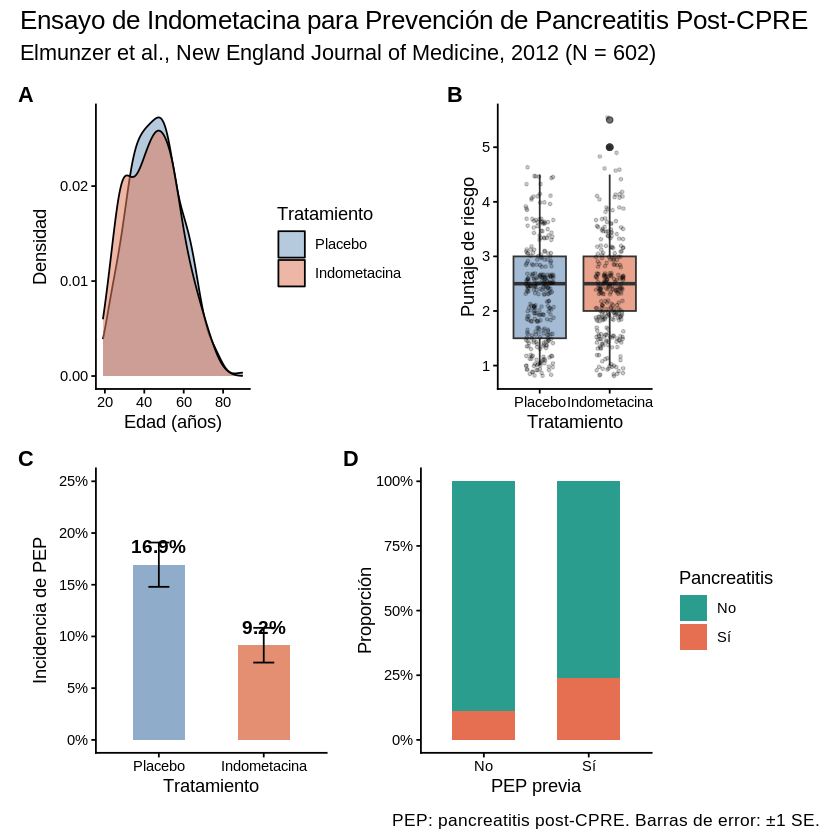

In [14]:
# Panel A: Densidad de edad por grupo
p_A <- ggplot(indo_clean, aes(x = age, fill = tratamiento)) +
  geom_density(alpha = 0.55) +
  scale_fill_manual(values = c("Placebo" = "#7B9EC1", "Indometacina" = "#E07B5A")) +
  labs(x = "Edad (años)", y = "Densidad", fill = "Tratamiento") +
  theme_classic()

# Panel B: Boxplot de riesgo
p_B <- ggplot(indo_clean, aes(x = tratamiento, y = risk, fill = tratamiento)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.2, size = 0.7) +
  scale_fill_manual(values = c("Placebo" = "#7B9EC1", "Indometacina" = "#E07B5A")) +
  labs(x = "Tratamiento", y = "Puntaje de riesgo") +
  theme_classic() + theme(legend.position = "none")

# Panel C: Incidencia del desenlace primario
prop2 <- indo_clean %>%
  group_by(tratamiento) %>%
  summarise(n_pep = sum(pancreatitis == "Sí"), n = n(),
            prop  = n_pep / n, se = sqrt(prop * (1 - prop) / n), .groups = "drop")

p_C <- ggplot(prop2, aes(x = tratamiento, y = prop, fill = tratamiento)) +
  geom_col(width = 0.5, alpha = 0.85) +
  geom_errorbar(aes(ymin = prop - se, ymax = prop + se), width = 0.2) +
  geom_text(aes(label = paste0(round(prop * 100, 1), "%")),
            vjust = -0.9, fontface = "bold", size = 4) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 0.25)) +
  scale_fill_manual(values = c("Placebo" = "#7B9EC1", "Indometacina" = "#E07B5A")) +
  labs(x = "Tratamiento", y = "Incidencia de PEP") +
  theme_classic() + theme(legend.position = "none")

# Panel D: Desenlace por pancreatitis previa
p_D <- indo_clean %>%
  count(pep_prev, pancreatitis) %>%
  group_by(pep_prev) %>% mutate(prop = n / sum(n)) %>%
  ggplot(aes(x = pep_prev, y = prop, fill = pancreatitis)) +
  geom_col(position = "fill", width = 0.6) +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("No" = "#2A9D8F", "Sí" = "#E76F51")) +
  labs(x = "PEP previa", y = "Proporción", fill = "Pancreatitis") +
  theme_classic()

# Ensamblar
(p_A | p_B) / (p_C | p_D) +
  plot_annotation(
    title    = "Ensayo de Indometacina para Prevención de Pancreatitis Post-CPRE",
    subtitle = "Elmunzer et al., New England Journal of Medicine, 2012 (N = 602)",
    caption  = "PEP: pancreatitis post-CPRE. Barras de error: ±1 SE.",
    tag_levels = "A"
  ) & theme(plot.tag = element_text(face = "bold", size = 13))

💡 **Operadores de `patchwork`:** `|` fila, `/` columna, `&` tema global, `plot_annotation(tag_levels="A")` para etiquetas.

---

---
## 🏁 Bloque 4 · Ejercicio Integrador y Cierre (10 min)

### Ejercicio integrador

Usando `strep_tb`, crea un panel de **2 gráficos**:

1. **Panel A:** Gráfico de barras con la proporción de cada resultado radiológico a 6 meses (`rad_num`) por brazo de tratamiento (`arm`).
2. **Panel B:** Boxplot de la condición basal (`baseline_condition`) por brazo de tratamiento.

Combina ambos paneles con `patchwork` y añade etiquetas **A** y **B**.

> **Pista:** Usa `glimpse(strep)` para ver todas las variables disponibles.

In [ ]:
# 🖊️ Ejercicio integrador — tu código aquí:

glimpse(strep)

# Panel A:


# Panel B:


# Combinar con patchwork:


---

## 💾 Exportar gráficos para publicación

In [15]:
# Guardar el último gráfico generado:
ggsave("figura1.pdf",  width = 10, height = 8, dpi = 300)  # vectorial
ggsave("figura1.tiff", width = 10, height = 8, dpi = 300)  # alta resolución
ggsave("figura1.png",  width = 10, height = 8, dpi = 300)  # web/presentaciones

# Guardar un gráfico específico:
ggsave("figura_A.pdf", plot = p_A, width = 6, height = 4, dpi = 300)

cat("Formatos recomendados para revistas biomédicas:\n")
cat("  PDF / SVG  → vectorial (Nature, NEJM, Lancet)\n")
cat("  TIFF 300+ → estándar en revistas clínicas\n")
cat("  PNG 300   → web y presentaciones\n")

Formatos recomendados para revistas biomédicas:
  PDF / SVG  → vectorial (Nature, NEJM, Lancet)
  TIFF 300+ → estándar en revistas clínicas
  PNG 300   → web y presentaciones


---

## 📋 Hoja de referencia rápida

### Geometrías frecuentes en biomedicina

| Función | Uso | Ejemplo biomédico |
|---------|-----|-------------------|
| `geom_point()` | Dispersión continua vs. continua | Biomarcador vs. respuesta clínica |
| `geom_line()` | Series de tiempo | Evolución de marcador tumoral |
| `geom_histogram()` | Distribución de variable continua | Edad en cohorte |
| `geom_density()` | Distribución suavizada | Comparar grupos |
| `geom_boxplot()` | Resumen de distribución por grupos | Expresión génica |
| `geom_violin()` | Distribución completa por grupos | Citometría de flujo |
| `geom_col()` | Barras con valores precomputados | Incidencia por grupo |
| `geom_tile()` | Heatmaps | Expresión diferencial |
| `geom_errorbar()` | Intervalos de error/confianza | Media ± SE |
| `geom_smooth()` | Tendencias | Curva dosis-respuesta |

### Estéticas (`aes()`)

| Estética | Descripción |
|----------|-------------|
| `x`, `y` | Posición |
| `color` | Color de borde/línea/punto |
| `fill` | Color de relleno |
| `size` | Tamaño |
| `shape` | Forma del punto |
| `alpha` | Transparencia |
| `linetype` | Tipo de línea |

---

## 📚 Recursos para continuar

- 📖 **ggplot2 book (libre):** https://ggplot2-book.org/
- 🎨 **R Graph Gallery:** https://r-graph-gallery.com/
- 📦 **Extensiones de ggplot2:** https://exts.ggplot2.tidyverse.org/gallery/
- 🏥 **medicaldata package:** https://higgi13425.github.io/medicaldata/
- 📰 **Elmunzer et al., NEJM 2012:** https://doi.org/10.1056/NEJMoa1111103


---

## ✅ Resumen del taller

1. Lógica de capas de la Gramática de Gráficos
2. Histogramas y densidades para explorar distribuciones clínicas
3. Mapear variables a estéticas (color, relleno, forma, tamaño)
4. Barras apiladas para visualizar proporciones (desenlaces binarios)
5. Boxplot + jitter para comparar grupos preservando datos individuales
6. `facet_wrap()` para análisis de subgrupos
7. Barras de error (media ± SE) para variables continuas
8. Violin plot con pruebas estadísticas (`ggpubr`)
9. Heatmap de correlaciones entre covariables
10. Panel multipanel para publicación con `patchwork`
11. Exportación en alta resolución con `ggsave()`

---

*Datasets: paquete `medicaldata` (Higgins 2021, CRAN). Licencia: MIT.*